In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print(f"\nUploaded ZIP File: {zip_file}")

extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("\nZIP Extracted Successfully!")
print("\nExtracted Files:")
print(os.listdir(extract_path))

Upload ZIP file from your PC


Saving rf_signal_dataset.zip to rf_signal_dataset.zip

Uploaded ZIP File: rf_signal_dataset.zip

ZIP Extracted Successfully!

Extracted Files:
['rf_signal_dataset.csv']


In [ ]:
import pandas as pd
import numpy as np
import os

print(os.listdir("/content/data"))

csv_path = "/content/data/rf_signal_dataset.csv"
header = pd.read_csv(csv_path, nrows=0)
feature_cols = [col for col in header.columns if col.startswith("f_")]
use_cols = feature_cols + ["modulation", "snr"]

dtype_dict = {col: np.float32 for col in feature_cols}
dtype_dict["snr"] = np.int8
dtype_dict["modulation"] = "category"

df = pd.read_csv(csv_path, usecols=use_cols, dtype=dtype_dict, engine="pyarrow")
print("\nDataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

df = df[df["snr"] > -10].reset_index(drop=True)
print("\nFiltered Shape:", df.shape)
print("\nRemaining SNR Values:")
print(sorted(df["snr"].unique()))

['rf_signal_dataset.csv']

Dataset Loaded Successfully!
Dataset Shape: (220000, 258)

Filtered Shape: (154000, 258)

Remaining SNR Values:
[np.int8(-8), np.int8(-6), np.int8(-4), np.int8(-2), np.int8(0), np.int8(2), np.int8(4), np.int8(6), np.int8(8), np.int8(10), np.int8(12), np.int8(14), np.int8(16), np.int8(18)]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

feature_cols = [col for col in df.columns if col.startswith("f_")]
X = df[feature_cols].to_numpy(dtype=np.float32)
y = df["modulation"].astype(str).to_numpy()
snr_values = df["snr"].to_numpy(dtype=np.float32)

mod_encoder = LabelEncoder()
y_encoded = mod_encoder.fit_transform(y)
class_names = mod_encoder.classes_
num_classes = len(class_names)

print("\nClasses:")
print(class_names)
print("\nNumber of Classes:", num_classes)

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y_encoded, snr_values, test_size=0.2, random_state=42, stratify=y_encoded)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)
print("\nTrain Labels:", y_train.shape)
print("Test Labels :", y_test.shape)

del X, y


Classes:
['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']

Number of Classes: 11

Train Shape: (123200, 256)
Test Shape : (30800, 256)

Train Labels: (123200,)
Test Labels : (30800,)


In [ ]:
import os,time,random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
MODEL2_CHECKPOINT_PATH="model2_residual_denoiser_checkpoint.pth"
MODEL2_BEST_PATH="best_model2_residual_denoiser.pth"
MODEL2_FINAL_PATH="final_model2_residual_denoiser.pth"
MODEL2_EPOCHS=35
MODEL2_PATIENCE=7
MODEL2_BATCH_SIZE=256
LR=0.0005
WEIGHT_DECAY=1e-4
torch.backends.cudnn.benchmark=True
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
if torch.cuda.is_available(): print("GPU:",torch.cuda.get_device_name(0))
def add_gaussian_noise(signal,noise_std=0.015): noise=np.random.normal(0,noise_std,signal.shape).astype(np.float32); return signal+noise
def random_shift(signal,max_shift=3): shift=np.random.randint(-max_shift,max_shift+1); return np.roll(signal,shift)
def amplitude_scaling(signal,low=0.95,high=1.05): scale=np.random.uniform(low,high); return signal*scale
def augment_rf_signal(signal):
    aug_signal=signal.copy()
    if random.random()<0.45: aug_signal=add_gaussian_noise(aug_signal,noise_std=0.015)
    if random.random()<0.25: aug_signal=random_shift(aug_signal,max_shift=3)
    if random.random()<0.25: aug_signal=amplitude_scaling(aug_signal,low=0.95,high=1.05)
    return aug_signal.astype(np.float32)
class RFDenoisingDataset(Dataset):
    def __init__(self,X,augment=True): self.X=X.astype(np.float32); self.augment=augment
    def __len__(self): return len(self.X)
    def __getitem__(self,idx):
        clean_signal=self.X[idx].copy()
        noisy_signal=augment_rf_signal(clean_signal) if self.augment else add_gaussian_noise(clean_signal,noise_std=0.015)
        noisy_signal=torch.tensor(noisy_signal,dtype=torch.float32).unsqueeze(0)
        clean_signal=torch.tensor(clean_signal,dtype=torch.float32).unsqueeze(0)
        return noisy_signal,clean_signal
train_denoise_dataset=RFDenoisingDataset(X_train,augment=True)
test_denoise_dataset=RFDenoisingDataset(X_test,augment=False)
train_denoise_loader=DataLoader(train_denoise_dataset,batch_size=MODEL2_BATCH_SIZE,shuffle=True,num_workers=2 if torch.cuda.is_available() else 0,pin_memory=torch.cuda.is_available())
test_denoise_loader=DataLoader(test_denoise_dataset,batch_size=MODEL2_BATCH_SIZE,shuffle=False,num_workers=2 if torch.cuda.is_available() else 0,pin_memory=torch.cuda.is_available())
print("Model 2 dataloaders ready.")
print("Train samples:",len(train_denoise_dataset))
print("Test samples :",len(test_denoise_dataset))
class ResidualBlock1D(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.conv1=nn.Conv1d(in_channels,out_channels,kernel_size=3,padding=1)
        self.bn1=nn.BatchNorm1d(out_channels)
        self.relu=nn.ReLU(inplace=True)
        self.conv2=nn.Conv1d(out_channels,out_channels,kernel_size=3,padding=1)
        self.bn2=nn.BatchNorm1d(out_channels)
        self.shortcut=nn.Identity()
        if in_channels!=out_channels: self.shortcut=nn.Sequential(nn.Conv1d(in_channels,out_channels,kernel_size=1),nn.BatchNorm1d(out_channels))
    def forward(self,x):
        identity=self.shortcut(x)
        out=self.relu(self.bn1(self.conv1(x)))
        out=self.bn2(self.conv2(out))
        return self.relu(out+identity)
class RFResidualDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_stem=nn.Sequential(nn.Conv1d(1,32,kernel_size=5,padding=2),nn.BatchNorm1d(32),nn.ReLU(inplace=True))
        self.encoder_block1=nn.Sequential(ResidualBlock1D(32,32),nn.MaxPool1d(2))
        self.encoder_block2=nn.Sequential(ResidualBlock1D(32,64),nn.MaxPool1d(2))
        self.encoder_block3=nn.Sequential(ResidualBlock1D(64,128),nn.MaxPool1d(2))
        self.bottleneck=nn.Sequential(ResidualBlock1D(128,128),nn.Dropout(0.10))
        self.up1=nn.Sequential(nn.Upsample(scale_factor=2,mode="linear",align_corners=False),nn.Conv1d(128,64,kernel_size=3,padding=1),nn.BatchNorm1d(64),nn.ReLU(inplace=True))
        self.dec_block1=ResidualBlock1D(64,64)
        self.up2=nn.Sequential(nn.Upsample(scale_factor=2,mode="linear",align_corners=False),nn.Conv1d(64,32,kernel_size=3,padding=1),nn.BatchNorm1d(32),nn.ReLU(inplace=True))
        self.dec_block2=ResidualBlock1D(32,32)
        self.up3=nn.Sequential(nn.Upsample(scale_factor=2,mode="linear",align_corners=False),nn.Conv1d(32,16,kernel_size=3,padding=1),nn.BatchNorm1d(16),nn.ReLU(inplace=True))
        self.residual_head=nn.Conv1d(16,1,kernel_size=3,padding=1)
    def forward(self,x):
        identity_input=x
        x=self.encoder_stem(x)
        x=self.encoder_block1(x)
        x=self.encoder_block2(x)
        x=self.encoder_block3(x)
        x=self.bottleneck(x)
        x=self.dec_block1(self.up1(x))
        x=self.dec_block2(self.up2(x))
        correction=self.residual_head(self.up3(x))
        return identity_input+correction
model2=RFResidualDenoisingAutoencoder().to(device)
print("\nImproved Model 2 created successfully.")
l1_loss=nn.L1Loss()
mse_loss=nn.MSELoss()
def denoise_loss(outputs,targets): return 0.7*l1_loss(outputs,targets)+0.3*mse_loss(outputs,targets)
optimizer_denoise=optim.AdamW(model2.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler_denoise=optim.lr_scheduler.ReduceLROnPlateau(optimizer_denoise,mode="min",factor=0.5,patience=2)
scaler_denoise=torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
start_epoch=0
best_val_loss=float("inf")
epochs_without_improvement=0
if os.path.exists(MODEL2_CHECKPOINT_PATH):
    print("\nFound Model 2 checkpoint. Resuming...")
    checkpoint=torch.load(MODEL2_CHECKPOINT_PATH,map_location=device)
    model2.load_state_dict(checkpoint["model_state_dict"])
    optimizer_denoise.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler_denoise.load_state_dict(checkpoint["scheduler_state_dict"])
    if scaler_denoise is not None and checkpoint["scaler_state_dict"] is not None: scaler_denoise.load_state_dict(checkpoint["scaler_state_dict"])
    start_epoch=checkpoint["epoch"]+1
    best_val_loss=checkpoint["best_val_loss"]
    epochs_without_improvement=checkpoint["epochs_without_improvement"]
    print(f"Resumed from epoch {start_epoch}")
else: print("\nNo previous improved Model 2 checkpoint found. Starting fresh.")
for epoch in range(start_epoch,MODEL2_EPOCHS):
    epoch_start=time.time()
    model2.train()
    train_loss=0.0
    for noisy_signals,clean_signals in train_denoise_loader:
        noisy_signals=noisy_signals.to(device,non_blocking=True)
        clean_signals=clean_signals.to(device,non_blocking=True)
        optimizer_denoise.zero_grad()
        if torch.cuda.is_available():
            with torch.cuda.amp.autocast():
                outputs=model2(noisy_signals)
                loss=denoise_loss(outputs,clean_signals)
            scaler_denoise.scale(loss).backward()
            scaler_denoise.unscale_(optimizer_denoise)
            torch.nn.utils.clip_grad_norm_(model2.parameters(),max_norm=1.0)
            scaler_denoise.step(optimizer_denoise)
            scaler_denoise.update()
        else:
            outputs=model2(noisy_signals)
            loss=denoise_loss(outputs,clean_signals)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model2.parameters(),max_norm=1.0)
            optimizer_denoise.step()
        train_loss+=loss.item()
    avg_train_loss=train_loss/len(train_denoise_loader)
    model2.eval()
    val_loss=0.0
    with torch.no_grad():
        for noisy_signals,clean_signals in test_denoise_loader:
            noisy_signals=noisy_signals.to(device,non_blocking=True)
            clean_signals=clean_signals.to(device,non_blocking=True)
            if torch.cuda.is_available():
                with torch.cuda.amp.autocast():
                    outputs=model2(noisy_signals)
                    loss=denoise_loss(outputs,clean_signals)
            else:
                outputs=model2(noisy_signals)
                loss=denoise_loss(outputs,clean_signals)
            val_loss+=loss.item()
    avg_val_loss=val_loss/len(test_denoise_loader)
    scheduler_denoise.step(avg_val_loss)
    current_lr=optimizer_denoise.param_groups[0]["lr"]
    if avg_val_loss<best_val_loss:
        best_val_loss=avg_val_loss
        epochs_without_improvement=0
        torch.save(model2.state_dict(),MODEL2_BEST_PATH)
        print("Best improved Model 2 updated.")
    else: epochs_without_improvement+=1
    checkpoint={"epoch":epoch,"model_state_dict":model2.state_dict(),"optimizer_state_dict":optimizer_denoise.state_dict(),"scheduler_state_dict":scheduler_denoise.state_dict(),"scaler_state_dict":scaler_denoise.state_dict() if scaler_denoise is not None else None,"best_val_loss":best_val_loss,"epochs_without_improvement":epochs_without_improvement}
    torch.save(checkpoint,MODEL2_CHECKPOINT_PATH)
    epoch_time=time.time()-epoch_start
    print(f"Epoch [{epoch+1}/{MODEL2_EPOCHS}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Best Val Loss: {best_val_loss:.6f} | LR: {current_lr:.6f} | Time: {epoch_time:.2f}s")
    if epochs_without_improvement>=MODEL2_PATIENCE:
        print("\nEarly stopping triggered for improved Model 2.")
        break
if os.path.exists(MODEL2_BEST_PATH):
    model2.load_state_dict(torch.load(MODEL2_BEST_PATH,map_location=device))
    print(f"\nLoaded best improved Model 2 from: {MODEL2_BEST_PATH}")
print(f"Best improved Model 2 Validation Loss: {best_val_loss:.6f}")
torch.save(model2.state_dict(),MODEL2_FINAL_PATH)
print("\nImproved Model 2 training completed.")
print("Saved files:")
print("-",MODEL2_CHECKPOINT_PATH)
print("-",MODEL2_BEST_PATH)
print("-",MODEL2_FINAL_PATH)

Using device: cuda
GPU: Tesla T4
Model 2 dataloaders ready.
Train samples: 123200
Test samples : 30800

Improved Model 2 created successfully.

Found Model 2 checkpoint. Resuming...


/tmp/ipykernel_2364/2412232222.py:263: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_denoise = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


Resumed from epoch 5


/tmp/ipykernel_2364/2412232222.py:310: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2364/2412232222.py:343: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Best improved Model 2 updated.
Epoch [6/35] | Train Loss: 0.003707 | Val Loss: 0.007092 | Best Val Loss: 0.007092 | LR: 0.000500 | Time: 33.12s
Best improved Model 2 updated.
Epoch [7/35] | Train Loss: 0.003501 | Val Loss: 0.006694 | Best Val Loss: 0.006694 | LR: 0.000500 | Time: 31.06s
Best improved Model 2 updated.
Epoch [8/35] | Train Loss: 0.003356 | Val Loss: 0.006386 | Best Val Loss: 0.006386 | LR: 0.000500 | Time: 30.67s
Best improved Model 2 updated.
Epoch [9/35] | Train Loss: 0.003187 | Val Loss: 0.006040 | Best Val Loss: 0.006040 | LR: 0.000500 | Time: 31.15s
Best improved Model 2 updated.
Epoch [10/35] | Train Loss: 0.002982 | Val Loss: 0.005397 | Best Val Loss: 0.005397 | LR: 0.000500 | Time: 30.63s
Best improved Model 2 updated.
Epoch [11/35] | Train Loss: 0.002784 | Val Loss: 0.004953 | Best Val Loss: 0.004953 | LR: 0.000500 | Time: 30.91s
Best improved Model 2 updated.
Epoch [12/35] | Train Loss: 0.002542 | Val Loss: 0.004349 | Best Val Loss: 0.004349 | LR: 0.000500 | Ti

In [ ]:
import torch
from google.colab import files

torch.save(model2.state_dict(),"best_model2_residual_denoiser.pth")
print("Model 2 saved successfully.")
files.download("best_model2_residual_denoiser.pth")

Model 2 saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Noisy MSE    : 0.0024119904
Denoised MSE : 0.0004023734


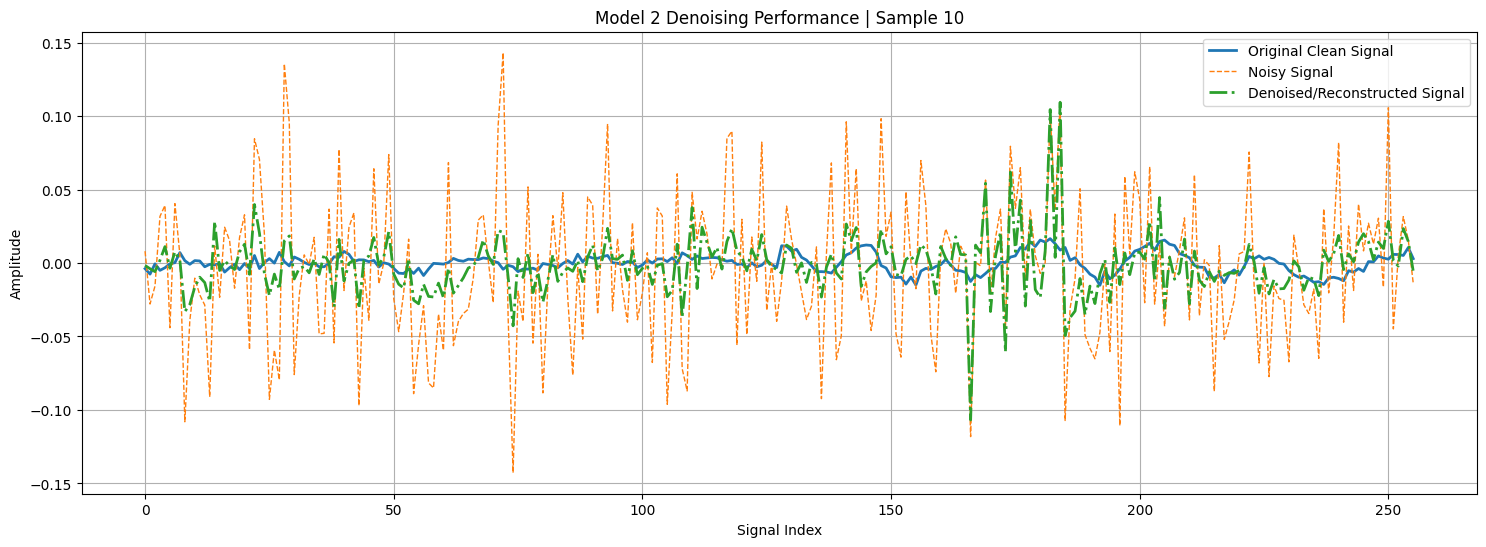

In [ ]:
model2.eval()
idx = 10

clean_signal = X_test[idx].astype(np.float32)
noise_std = 0.05
noise = np.random.normal(0, noise_std, clean_signal.shape).astype(np.float32)
noisy_signal = clean_signal + noise

with torch.no_grad():
    noisy_tensor = torch.tensor(noisy_signal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    denoised_tensor = model2(noisy_tensor)

denoised_signal = denoised_tensor.squeeze().cpu().numpy()

noisy_mse = np.mean((clean_signal - noisy_signal) ** 2)
denoised_mse = np.mean((clean_signal - denoised_signal) ** 2)

print("Noisy MSE    :", noisy_mse)
print("Denoised MSE :", denoised_mse)

plt.figure(figsize=(18, 6))
plt.plot(clean_signal, label="Original Clean Signal", linewidth=2)
plt.plot(noisy_signal, label="Noisy Signal", linestyle="--", linewidth=1)
plt.plot(denoised_signal, label="Denoised/Reconstructed Signal", linestyle="-.", linewidth=2)
plt.title(f"Model 2 Denoising Performance | Sample {idx}")
plt.xlabel("Signal Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


torch.save( model3.state_dict(), "best_model3_mid_high.pth")
print("Model 3 saved successfully.")
files.download("best_model3_mid_high.pth")

Model 3 saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os,time,random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from sklearn.metrics import classification_report,confusion_matrix

MODEL2_BEST_PATH="best_model2_residual_denoiser.pth"
CHECKPOINT_PATH="model3_transformer_mid_high_checkpoint.pth"
BEST_MODEL_PATH="best_model3_transformer_mid_high.pth"
FINAL_MODEL_PATH="final_model3_transformer_mid_high.pth"
EPOCHS=50
PATIENCE=8
BATCH_SIZE=256
LR=0.0005
WEIGHT_DECAY=1e-4
ALPHA_DENOISED=0.40
SEED=42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark=True
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names=mod_encoder.classes_
num_classes=len(class_names)

print("Classes:",class_names)
print("Number of classes:",num_classes)
print("Using device:",device)

if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))

class ResidualBlock1D(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.conv1=nn.Conv1d(in_channels,out_channels,kernel_size=3,padding=1)
        self.bn1=nn.BatchNorm1d(out_channels)
        self.relu=nn.ReLU(inplace=True)
        self.conv2=nn.Conv1d(out_channels,out_channels,kernel_size=3,padding=1)
        self.bn2=nn.BatchNorm1d(out_channels)
        self.shortcut=nn.Identity()
        if in_channels!=out_channels:
            self.shortcut=nn.Sequential(nn.Conv1d(in_channels,out_channels,kernel_size=1),nn.BatchNorm1d(out_channels))
    def forward(self,x):
        identity=self.shortcut(x)
        out=self.relu(self.bn1(self.conv1(x)))
        out=self.bn2(self.conv2(out))
        return self.relu(out+identity)

class RFResidualDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_stem=nn.Sequential(nn.Conv1d(1,32,kernel_size=5,padding=2),nn.BatchNorm1d(32),nn.ReLU(inplace=True))
        self.encoder_block1=nn.Sequential(ResidualBlock1D(32,32),nn.MaxPool1d(2))
        self.encoder_block2=nn.Sequential(ResidualBlock1D(32,64),nn.MaxPool1d(2))
        self.encoder_block3=nn.Sequential(ResidualBlock1D(64,128),nn.MaxPool1d(2))
        self.bottleneck=nn.Sequential(ResidualBlock1D(128,128),nn.Dropout(0.10))
        self.up1=nn.Sequential(nn.Upsample(scale_factor=2,mode="linear",align_corners=False),nn.Conv1d(128,64,kernel_size=3,padding=1),nn.BatchNorm1d(64),nn.ReLU(inplace=True))
        self.dec_block1=ResidualBlock1D(64,64)
        self.up2=nn.Sequential(nn.Upsample(scale_factor=2,mode="linear",align_corners=False),nn.Conv1d(64,32,kernel_size=3,padding=1),nn.BatchNorm1d(32),nn.ReLU(inplace=True))
        self.dec_block2=ResidualBlock1D(32,32)
        self.up3=nn.Sequential(nn.Upsample(scale_factor=2,mode="linear",align_corners=False),nn.Conv1d(32,16,kernel_size=3,padding=1),nn.BatchNorm1d(16),nn.ReLU(inplace=True))
        self.residual_head=nn.Conv1d(16,1,kernel_size=3,padding=1)
    def forward(self,x):
        identity_input=x
        x=self.encoder_stem(x)
        x=self.encoder_block1(x)
        x=self.encoder_block2(x)
        x=self.encoder_block3(x)
        x=self.bottleneck(x)
        x=self.dec_block1(self.up1(x))
        x=self.dec_block2(self.up2(x))
        correction=self.residual_head(self.up3(x))
        return identity_input+correction

model2=RFResidualDenoisingAutoencoder().to(device)

if os.path.exists(MODEL2_BEST_PATH):
    model2.load_state_dict(torch.load(MODEL2_BEST_PATH,map_location=device))
    print("Loaded Model 2:",MODEL2_BEST_PATH)
else:
    raise FileNotFoundError(f"{MODEL2_BEST_PATH} not found. Train Model 2 first.")

model2.eval()

def generate_denoised_data(model2,X,batch_size=512):
    model2.eval()
    denoised_list=[]
    with torch.no_grad():
        for i in range(0,len(X),batch_size):
            batch=X[i:i+batch_size].astype(np.float32)
            batch_tensor=torch.tensor(batch,dtype=torch.float32).unsqueeze(1).to(device)
            outputs=model2(batch_tensor).squeeze(1).cpu().numpy()
            denoised_list.append(outputs)
    return np.vstack(denoised_list).astype(np.float32)

print("\nGenerating denoised train data...")
X_train_denoised=generate_denoised_data(model2,X_train)

print("Generating denoised test data...")
X_test_denoised=generate_denoised_data(model2,X_test)

print("Raw train shape     :",X_train.shape)
print("Denoised train shape:",X_train_denoised.shape)
print("Raw test shape      :",X_test.shape)
print("Denoised test shape :",X_test_denoised.shape)

X_train_fused=(ALPHA_DENOISED*X_train_denoised)+((1-ALPHA_DENOISED)*X_train)
X_test_fused=(ALPHA_DENOISED*X_test_denoised)+((1-ALPHA_DENOISED)*X_test)

snr_mean=np.mean(snr_train)
snr_std=np.std(snr_train)+1e-8
snr_train_norm=((snr_train-snr_mean)/snr_std).astype(np.float32)
snr_test_norm=((snr_test-snr_mean)/snr_std).astype(np.float32)

def add_noise(signal,noise_std=0.004):
    noise=np.random.normal(0,noise_std,signal.shape).astype(np.float32)
    return signal+noise

def random_shift(signal,max_shift=2):
    shift=np.random.randint(-max_shift,max_shift+1)
    return np.roll(signal,shift,axis=1)

def amplitude_scaling(signal,low=0.97,high=1.03):
    scale=np.random.uniform(low,high)
    return signal*scale

class Model3TransformerDataset(Dataset):
    def __init__(self,X_raw,X_fused,y,snr,augment=False):
        self.X_raw=X_raw.astype(np.float32)
        self.X_fused=X_fused.astype(np.float32)
        self.y=y
        self.snr=snr.astype(np.float32)
        self.augment=augment
    def __len__(self):
        return len(self.X_raw)
    def __getitem__(self,idx):
        raw=self.X_raw[idx].reshape(2,128)
        fused=self.X_fused[idx].reshape(2,128)
        signal=np.concatenate([raw,fused],axis=0)
        if self.augment:
            if random.random()<0.20:
                signal=add_noise(signal)
            if random.random()<0.20:
                signal=random_shift(signal)
            if random.random()<0.20:
                signal=amplitude_scaling(signal)
        signal=torch.tensor(signal,dtype=torch.float32)
        snr_value=torch.tensor([self.snr[idx]],dtype=torch.float32)
        label=torch.tensor(self.y[idx],dtype=torch.long)
        return signal,snr_value,label

train_dataset=Model3TransformerDataset(X_train,X_train_fused,y_train,snr_train_norm,augment=True)
test_dataset=Model3TransformerDataset(X_test,X_test_fused,y_test,snr_test_norm,augment=False)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2 if torch.cuda.is_available() else 0,pin_memory=torch.cuda.is_available(),persistent_workers=True if torch.cuda.is_available() else False)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2 if torch.cuda.is_available() else 0,pin_memory=torch.cuda.is_available(),persistent_workers=True if torch.cuda.is_available() else False)

print("\nTransformer Model 3 dataloaders ready.")
print("Train samples:",len(train_dataset))
print("Test samples :",len(test_dataset))

class ResidualCNNBlock1D(nn.Module):
    def __init__(self,in_channels,out_channels,kernel_size=3,dropout=0.2,pool=True):
        super().__init__()
        padding=kernel_size//2
        self.conv1=nn.Conv1d(in_channels,out_channels,kernel_size=kernel_size,padding=padding)
        self.bn1=nn.BatchNorm1d(out_channels)
        self.relu=nn.ReLU(inplace=True)
        self.conv2=nn.Conv1d(out_channels,out_channels,kernel_size=kernel_size,padding=padding)
        self.bn2=nn.BatchNorm1d(out_channels)
        self.shortcut=nn.Identity()
        if in_channels!=out_channels:
            self.shortcut=nn.Sequential(nn.Conv1d(in_channels,out_channels,kernel_size=1),nn.BatchNorm1d(out_channels))
        self.dropout=nn.Dropout(dropout)
        self.pool=nn.MaxPool1d(2) if pool else nn.Identity()
    def forward(self,x):
        identity=self.shortcut(x)
        out=self.relu(self.bn1(self.conv1(x)))
        out=self.bn2(self.conv2(out))
        out=self.relu(out+identity)
        out=self.dropout(out)
        return self.pool(out)

class TransformerEncoderBlock(nn.Module):
    def __init__(self,embed_dim=256,num_heads=8,ff_dim=512,dropout=0.25):
        super().__init__()
        encoder_layer=nn.TransformerEncoderLayer(d_model=embed_dim,nhead=num_heads,dim_feedforward=ff_dim,dropout=dropout,batch_first=True,activation="gelu",norm_first=True)
        self.transformer=nn.TransformerEncoder(encoder_layer,num_layers=1)
        self.layer_norm=nn.LayerNorm(embed_dim)
    def forward(self,x):
        return self.layer_norm(self.transformer(x)+x)

class AttentionLayer(nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        self.attention=nn.Sequential(nn.Linear(hidden_dim,hidden_dim//2),nn.Tanh(),nn.Linear(hidden_dim//2,1))
    def forward(self,sequence_output):
        scores=self.attention(sequence_output)
        weights=torch.softmax(scores,dim=1)
        context=torch.sum(weights*sequence_output,dim=1)
        return context,weights

class Model3CNNTransformerAttentionSNR(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.cnn_block1=ResidualCNNBlock1D(4,64,kernel_size=7,dropout=0.15,pool=True)
        self.cnn_block2=ResidualCNNBlock1D(64,128,kernel_size=5,dropout=0.20,pool=True)
        self.cnn_block3=ResidualCNNBlock1D(128,256,kernel_size=3,dropout=0.25,pool=False)
        self.transformer1=TransformerEncoderBlock(embed_dim=256,num_heads=8,ff_dim=512,dropout=0.25)
        self.transformer2=TransformerEncoderBlock(embed_dim=256,num_heads=8,ff_dim=512,dropout=0.25)
        self.attention=AttentionLayer(hidden_dim=256)
        self.snr_branch=nn.Sequential(nn.Linear(1,16),nn.ReLU(),nn.Linear(16,32),nn.ReLU())
        self.classifier=nn.Sequential(nn.Linear(256+32,256),nn.ReLU(),nn.Dropout(0.40),nn.Linear(256,128),nn.ReLU(),nn.Dropout(0.30),nn.Linear(128,num_classes))
    def forward(self,x,snr):
        x=self.cnn_block1(x)
        x=self.cnn_block2(x)
        x=self.cnn_block3(x)
        x=x.permute(0,2,1)
        x=self.transformer1(x)
        x=self.transformer2(x)
        context,attention_weights=self.attention(x)
        snr_features=self.snr_branch(snr)
        combined=torch.cat([context,snr_features],dim=1)
        return self.classifier(combined)

model3=Model3CNNTransformerAttentionSNR(num_classes=num_classes).to(device)
print("\nModel 3 Transformer created successfully.")

criterion=nn.CrossEntropyLoss()
optimizer=optim.AdamW(model3.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=3)
scaler=torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

start_epoch=0
best_val_acc=0.0
epochs_without_improvement=0

if os.path.exists(CHECKPOINT_PATH):
    checkpoint=torch.load(CHECKPOINT_PATH,map_location=device)
    model3.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch=checkpoint["epoch"]+1
    best_val_acc=checkpoint["best_val_acc"]
    epochs_without_improvement=checkpoint["epochs_without_improvement"]
    print(f"\nResuming Transformer Model 3 from epoch {start_epoch}")

def train_one_epoch(model,loader):
    model.train()
    total_loss=0
    correct=0
    total=0
    for signals,snr_values,labels in loader:
        signals=signals.to(device,non_blocking=True)
        snr_values=snr_values.to(device,non_blocking=True)
        labels=labels.to(device,non_blocking=True)
        optimizer.zero_grad()
        if torch.cuda.is_available():
            with torch.cuda.amp.autocast():
                outputs=model(signals,snr_values)
                loss=criterion(outputs,labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs=model(signals,snr_values)
            loss=criterion(outputs,labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            optimizer.step()
        total_loss+=loss.item()
        preds=torch.argmax(outputs,dim=1)
        correct+=(preds==labels).sum().item()
        total+=labels.size(0)
    return total_loss/len(loader),correct/total

def evaluate(model,loader):
    model.eval()
    total_loss=0
    correct=0
    total=0
    all_preds=[]
    all_labels=[]
    with torch.no_grad():
        for signals,snr_values,labels in loader:
            signals=signals.to(device,non_blocking=True)
            snr_values=snr_values.to(device,non_blocking=True)
            labels=labels.to(device,non_blocking=True)
            outputs=model(signals,snr_values)
            loss=criterion(outputs,labels)
            total_loss+=loss.item()
            preds=torch.argmax(outputs,dim=1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader),correct/total,all_preds,all_labels

def print_classwise_accuracy(y_true,y_pred,class_names):
    cm=confusion_matrix(y_true,y_pred)
    print("\nClass-wise Accuracy:")
    for i,class_name in enumerate(class_names):
        total=cm[i].sum()
        correct=cm[i][i]
        acc=correct/total if total>0 else 0
        print(f"{class_name}: {acc:.4f}")

for epoch in range(start_epoch,EPOCHS):
    start_time=time.time()
    train_loss,train_acc=train_one_epoch(model3,train_loader)
    val_loss,val_acc,all_preds,all_labels=evaluate(model3,test_loader)
    scheduler.step(val_acc)
    current_lr=optimizer.param_groups[0]["lr"]
    if val_acc>best_val_acc:
        best_val_acc=val_acc
        epochs_without_improvement=0
        torch.save(model3.state_dict(),BEST_MODEL_PATH)
        print("\nBest Transformer Model 3 saved.")
    else:
        epochs_without_improvement+=1
    checkpoint={"epoch":epoch,"model_state_dict":model3.state_dict(),"optimizer_state_dict":optimizer.state_dict(),"scheduler_state_dict":scheduler.state_dict(),"best_val_acc":best_val_acc,"epochs_without_improvement":epochs_without_improvement}
    torch.save(checkpoint,CHECKPOINT_PATH)
    epoch_time=time.time()-start_time
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Best Val Acc: {best_val_acc:.4f} | LR: {current_lr:.6f} | Time: {epoch_time:.2f}s")
    if epochs_without_improvement>=PATIENCE:
        print("\nEarly stopping triggered for Transformer Model 3.")
        break

if os.path.exists(BEST_MODEL_PATH):
    model3.load_state_dict(torch.load(BEST_MODEL_PATH,map_location=device))
    print(f"\nLoaded best Transformer Model 3 from: {BEST_MODEL_PATH}")

print(f"\nBest Transformer Model 3 Validation Accuracy: {best_val_acc:.4f}")
final_loss,final_acc,final_preds,final_labels=evaluate(model3,test_loader)
print(f"\nFinal Test Accuracy using Best Transformer Model 3: {final_acc:.4f}")
print(f"Final Test Loss using Best Transformer Model 3: {final_loss:.4f}")
print("\nClassification Report:\n")
print(classification_report(final_labels,final_preds,target_names=class_names))
print_classwise_accuracy(final_labels,final_preds,class_names)
print("\nConfusion Matrix:\n")
print(confusion_matrix(final_labels,final_preds))
torch.save(model3.state_dict(),FINAL_MODEL_PATH)
print("\nTransformer Model 3 training completed.")
print("Saved files:")
print("-",CHECKPOINT_PATH)
print("-",BEST_MODEL_PATH)
print("-",FINAL_MODEL_PATH)

Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Number of classes: 11
Using device: cuda
GPU: Tesla T4
Loaded Model 2: best_model2_residual_denoiser.pth

Generating denoised train data...
Generating denoised test data...
Raw train shape     : (123200, 256)
Denoised train shape: (123200, 256)
Raw test shape      : (30800, 256)
Denoised test shape : (30800, 256)

Transformer Model 3 dataloaders ready.
Train samples: 123200
Test samples : 30800

Model 3 Transformer created successfully.


/tmp/ipykernel_2364/1768063127.py:395: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_2364/1768063127.py:541: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_2364/1768063127.py:583: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Best Transformer Model 3 saved.

Epoch [1/50] | Train Loss: 0.8386 | Train Acc: 0.6344 | Val Loss: 0.6615 | Val Acc: 0.7202 | Best Val Acc: 0.7202 | LR: 0.000500 | Time: 18.45s

Epoch [2/50] | Train Loss: 0.5315 | Train Acc: 0.7526 | Val Loss: 0.7487 | Val Acc: 0.6947 | Best Val Acc: 0.7202 | LR: 0.000500 | Time: 17.16s

Best Transformer Model 3 saved.

Epoch [3/50] | Train Loss: 0.4819 | Train Acc: 0.7733 | Val Loss: 0.5397 | Val Acc: 0.7522 | Best Val Acc: 0.7522 | LR: 0.000500 | Time: 17.52s

Best Transformer Model 3 saved.

Epoch [4/50] | Train Loss: 0.4604 | Train Acc: 0.7838 | Val Loss: 0.5414 | Val Acc: 0.7558 | Best Val Acc: 0.7558 | LR: 0.000500 | Time: 17.59s

Epoch [5/50] | Train Loss: 0.4409 | Train Acc: 0.7947 | Val Loss: 1.3206 | Val Acc: 0.6577 | Best Val Acc: 0.7558 | LR: 0.000500 | Time: 17.42s

Best Transformer Model 3 saved.

Epoch [6/50] | Train Loss: 0.4285 | Train Acc: 0.8039 | Val Loss: 0.4771 | Val Acc: 0.7910 | Best Val Acc: 0.7910 | LR: 0.000500 | Time: 17.29

# Detailed Model Flowchart

```text
CLEAN RF SIGNAL
       │
       ▼
   Add AWGN
       │
       ▼
NOISY / RAW SIGNAL
       │
       ▼
┌─────────────────────────────┐
│          RDAE               │
│                             │
│ Encoder Stem                │
│      ↓                      │
│ 3 Residual Encoder Blocks   │
│      ↓                      │
│ Residual Bottleneck         │
│      ↓                      │
│ 2 Residual Decoder Blocks   │
│      ↓                      │
│ Residual Head               │
└─────────────┬───────────────┘
              │
              ▼
     Residual Correction
              │
              ▼
 Xdenoised = Xraw + R(Xraw)
              │
              ▼
      DENOISED SIGNAL
              │
        ┌─────┴─────┐
        │           │
        ▼           ▼
   RAW SIGNAL   DENOISED
        │           │
        └─────┬─────┘
              ▼
      WEIGHTED FUSION
              │
              ▼
 Xfused = 0.40 Xdenoised
        + 0.60 Xraw
              │
              ▼
 Raw (2×128) + Fused (2×128)
              │
              ▼
       FINAL 4×128 INPUT
              │
              ▼
┌─────────────────────────────┐
│       CLASSIFIER            │
│                             │
│ Residual CNN Block 1        │
│         ↓                   │
│ Residual CNN Block 2        │
│         ↓                   │
│ Residual CNN Block 3        │
│         ↓                   │
│ Transformer Encoder 1       │
│         ↓                   │
│ Transformer Encoder 2       │
│         ↓                   │
│ Attention Layer             │
└─────────────┬───────────────┘
              │
              ├──────── SNR Branch
              │
              ▼
       Feature Concatenation
              │
              ▼
          Classifier
              │
              ▼
   MODULATION CLASS PREDICTION